# BiLSTMAttention Neural Network - Smart MCQ Solver (With Wandb Epoch Loss Curves)

### Overview and Wandb Tracking Features
This notebook implements a **Bidirectional LSTM with Attention (BiLSTMAttention)** deep learning model in PyTorch for the **Smart MCQ Solver Challenge** with **Epoch-Wise Loss Curves, Average Loss Metrics, and Fold Progression**.

- **Primary Kaggle Metric**: MAP@3 (Mean Average Precision at 3)
- **Secondary Evaluation Metrics**:
  - Top-1 Accuracy: Standard classification accuracy.
  - Top-3 Accuracy: Recall metric checking if ground truth is within top 3 ranked answers.
  - F1-Score (Macro): Harmonic mean of precision and recall.
  - Precision and Recall (Macro)
  - Log Loss: Binary Cross Entropy of option probability predictions.

- **Wandb Dashboard Loss Charts and Visualizations**:
  - Epoch-Wise Average Training Loss (`epoch/avg_train_loss`)
  - Epoch-Wise Average Validation Loss (`epoch/avg_val_loss`)
  - Epoch-Wise MAP@3 Score Curve (`epoch/val_map3`)
  - Automatic Matplotlib Loss & Metric Progression Curves.

---


In [1]:
# Cell 1: Core Imports and Setup
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, log_loss
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Core libraries imported successfully! Device: {device}")


Core libraries imported successfully! Device: cuda


In [2]:
# Cell 2: Weights and Biases (Wandb) Setup
try:
    import wandb
    WANDB_API_KEY = "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"
    WANDB_ENTITY = "models-indian-institute-of-technology-madras481" 
    WANDB_PROJECT = "23f3001092-t22026"

    wandb.login(key=WANDB_API_KEY)
    USE_WANDB = True
    print("Wandb initialized successfully!")
except Exception as e:
    USE_WANDB = False
    print(f"Wandb running in offline fallback mode ({e})")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Wandb initialized successfully!


In [3]:
# Cell 3: Dataset Loading and Preprocessing
def load_datasets():
    train_candidates = [
        "train.csv",
        "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv",
        "/kaggle/input/smart-mcq-solver-challenge/train.csv"
    ]
    test_candidates = [
        "test.csv",
        "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv",
        "/kaggle/input/smart-mcq-solver-challenge/test.csv"
    ]
    
    train_path = next((p for p in train_candidates if os.path.exists(p)), train_candidates[0])
    test_path = next((p for p in test_candidates if os.path.exists(p)), test_candidates[0])
    
    df_train = pd.read_csv(train_path).fillna('')
    df_test = pd.read_csv(test_path).fillna('')
    
    return df_train, df_test

train_df, test_df = load_datasets()
OPTION_COLS = ['A', 'B', 'C', 'D', 'E']

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
train_df.head(3)


Train shape: (2000, 8)
Test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [4]:
# Cell 4: Evaluation Metric Functions
def apk(actual, predicted, k=3):
    if actual in predicted[:k]:
        return 1.0 / (predicted[:k].index(actual) + 1.0)
    return 0.0

def mapk(actuals, preds, k=3):
    return float(np.mean([apk(a, p, k) for a, p in zip(actuals, preds)]))

def compute_all_metrics(actuals, pred_lists):
    map3_score = mapk(actuals, pred_lists)
    top1_preds = [p[0] for p in pred_lists]
    top1_acc = accuracy_score(actuals, top1_preds)
    top3_acc = np.mean([1 if a in p[:3] else 0 for a, p in zip(actuals, pred_lists)])
    prec, rec, f1, _ = precision_recall_fscore_support(actuals, top1_preds, average='macro', zero_division=0)
    
    return {
        'map3': map3_score,
        'top1_accuracy': top1_acc,
        'top3_accuracy': top3_acc,
        'f1_score': f1,
        'precision': prec,
        'recall': rec
    }

def rank_preds(pw, scores, orig_df):
    pw_temp = pw.copy()
    pw_temp['score'] = scores
    
    ranked = pw_temp.sort_values(['qid', 'score'], ascending=[True, False])
    grouped = ranked.groupby('qid')['option'].apply(lambda opts: list(opts)[:3]).to_dict()
    
    return [grouped.get(qid, ['A', 'B', 'C']) for qid in orig_df['id']]


In [5]:
# Cell 5: Tokenizer, RAG Context Builder, and Pairwise Dataset Creation

# ─── RAG: Retrieve context from train for each question ───────────────────────
# How it works:
# 1. Build TF-IDF vectors of all train prompts
# 2. For every question (train + test), find the most similar train question
# 3. Retrieve the CORRECT answer text from that similar question
# 4. Append it as "Context: <text>" to each pairwise row
# This is called "in-context RAG" — no external API, works fully offline
# For this dataset: 268/500 test questions have sim=1.0 with a train question
# meaning we retrieve the exact correct answer as context for 54% of test questions!

from sklearn.feature_extraction.text import TfidfVectorizer as TfidfVec
from sklearn.metrics.pairwise import cosine_similarity

def build_rag_context(train_df):
    """
    Returns a dict: question_id -> context string
    Context = correct answer text from most similar train question
    """
    tfidf_rag = TfidfVec(max_features=20000, ngram_range=(1,2))
    train_vecs = tfidf_rag.fit_transform(train_df['prompt'])

    def get_context(query_prompt, exclude_id=None):
        q_vec = tfidf_rag.transform([query_prompt])
        sims  = cosine_similarity(q_vec, train_vecs)[0]
        # exclude self (for train questions)
        if exclude_id is not None:
            idx = train_df[train_df['id'] == exclude_id].index
            if len(idx) > 0:
                sims[idx[0]] = -1
        best_idx = sims.argmax()
        best_row = train_df.iloc[best_idx]
        correct_opt = best_row['answer']
        context_text = str(best_row[correct_opt])
        sim_score = sims[best_idx]
        return context_text, sim_score

    return tfidf_rag, train_vecs, get_context

print("Building RAG context index from train...")
tfidf_rag, train_vecs_rag, get_context = build_rag_context(train_df)

# Pre-compute context for all train and test questions
print("Computing contexts for train questions...")
train_contexts = {}
for _, r in train_df.iterrows():
    ctx, sim = get_context(r['prompt'], exclude_id=r['id'])
    train_contexts[r['id']] = (ctx, sim)

print("Computing contexts for test questions...")
test_contexts = {}
for _, r in test_df.iterrows():
    ctx, sim = get_context(r['prompt'], exclude_id=None)
    test_contexts[r['id']] = (ctx, sim)

# Stats
train_sims = [v[1] for v in train_contexts.values()]
test_sims  = [v[1] for v in test_contexts.values()]
print(f"Train avg retrieval sim: {np.mean(train_sims):.3f}")
print(f"Test  avg retrieval sim: {np.mean(test_sims):.3f}")
print(f"Test exact matches (sim>=0.99): {sum(1 for s in test_sims if s >= 0.99)}/500")

# ─── Tokenizer ────────────────────────────────────────────────────────────────
class FastTextTokenizer:
    def __init__(self, max_features=40000):
        self.max_features = max_features
        self.word2id = {"<PAD>": 0, "<UNK>": 1}
        self.word_counts = {}

    def fit_on_texts(self, texts):
        for text in texts:
            words = re.findall(r'\w+', str(text).lower())
            for word in words:
                self.word_counts[word] = self.word_counts.get(word, 0) + 1
        sorted_words = sorted(self.word_counts.items(), key=lambda x: x[1], reverse=True)
        for idx, (word, _) in enumerate(sorted_words[:self.max_features - 2]):
            self.word2id[word] = idx + 2

    def texts_to_sequences(self, texts, max_len=300):
        sequences = []
        for text in texts:
            words = re.findall(r'\w+', str(text).lower())
            seq = [self.word2id.get(w, 1) for w in words[:max_len]]
            if len(seq) < max_len:
                seq += [0] * (max_len - len(seq))
            sequences.append(seq)
        return np.array(sequences, dtype=np.int64)

# ─── Pairwise Dataset with RAG Context ────────────────────────────────────────
def make_pairwise_df(df, is_train=True, context_dict=None):
    """
    Text format WITH RAG:
    "Question: <prompt> [CTX] Context: <retrieved_correct_answer> [SEP] Option: <option>"
    
    The [CTX] block gives the model a hint about what the correct answer looks like.
    For exact-match questions, this is the actual correct answer text.
    """
    rows = []
    for _, r in df.iterrows():
        qid    = r['id']
        prompt = str(r['prompt'])
        ans    = r.get('answer', None)

        # Get RAG context for this question
        if context_dict and qid in context_dict:
            ctx_text = context_dict[qid][0]
            ctx_part = f" [CTX] Context: {ctx_text[:200]}"
        else:
            ctx_part = ""

        for opt in OPTION_COLS:
            opt_str  = str(r[opt])
            combined = f"Question: {prompt}{ctx_part} [SEP] Option: {opt_str}"
            row = {'qid': qid, 'option': opt, 'text': combined}
            if is_train:
                row['label'] = 1 if (ans == opt) else 0
            rows.append(row)
    return pd.DataFrame(rows)

pair_train = make_pairwise_df(train_df, is_train=True,  context_dict=train_contexts)
pair_test  = make_pairwise_df(test_df,  is_train=False, context_dict=test_contexts)

tokenizer = FastTextTokenizer(max_features=40000)
tokenizer.fit_on_texts(pd.concat([pair_train['text'], pair_test['text']]))

X_all_train = tokenizer.texts_to_sequences(pair_train['text'], max_len=300)
X_all_test  = tokenizer.texts_to_sequences(pair_test['text'],  max_len=300)

y_all_train      = pair_train['label'].values
groups_all_train = pair_train['qid'].values

print(f"\nPairwise Train Shape: {pair_train.shape}")
print(f"Pairwise Test  Shape: {pair_test.shape}")
print(f"Sequence length: 300 (increased from 256 to fit context)")
print(f"\nSample RAG text:")
print(pair_train['text'].iloc[0][:200])


In [6]:
# Cell 6: PyTorch BiLSTMAttention Architecture
class Attention(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.attn = nn.Linear(feature_dim, 1)

    def forward(self, x):
        weights = torch.tanh(self.attn(x))
        weights = F.softmax(weights, dim=1)
        context = torch.sum(x * weights, dim=1)
        return context

class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim=256, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
        self.attention = Attention(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        lstm_out, _ = self.lstm(embedded)
        context = self.attention(lstm_out)
        logits = self.fc(context).squeeze(-1)
        return logits

class MCQDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

print("BiLSTMAttention architecture loaded.")


BiLSTMAttention architecture loaded.


In [7]:
# Cell 7: 5-Fold Training Loop with Epoch-Wise Loss Curves and Wandb Logging
gkf = GroupKFold(n_splits=5)

oof_bilstm = np.zeros(len(pair_train))
tst_bilstm = np.zeros(len(pair_test))

config_dict = {
    "architecture": "BiLSTMAttention Neural Network",
    "dataset": "Smart MCQ Solver Challenge",
    "vocab_size": 40000,
    "embedding_dim": 256,
    "hidden_dim": 128,
    "max_len": 256,
    "learning_rate": 2e-3,
    "weight_decay": 1e-4,
    "epochs": 5,
    "batch_size": 64,
    "n_splits": 5
}

if USE_WANDB:
    run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name="scrach-bilstm-epoch-loss-charts",
        config=config_dict
    )

print("\nStarting 5-Fold BiLSTMAttention Training with Epoch Loss Curves...")

# Track loss curves across epochs for plotting
history_train_loss = []
history_val_loss = []
history_val_map3 = []

for fold, (ti, vi) in enumerate(gkf.split(X_all_train, y_all_train, groups_all_train)):
    print(f"\n--- Fold {fold+1}/5 ---")
    
    train_ds = MCQDataset(X_all_train[ti], y_all_train[ti])
    val_ds = MCQDataset(X_all_train[vi], y_all_train[vi])
    
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
    
    model = BiLSTMAttention(vocab_size=40000, embedding_dim=256, hidden_dim=128).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    
    best_val_loss = float('inf')
    best_val_probs = None
    
    for epoch in range(5):
        # 1. Training Phase (Compute Average Training Loss)
        model.train()
        running_train_loss = 0.0
        total_train_batches = 0
        
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            running_train_loss += loss.item()
            total_train_batches += 1
            
        avg_train_loss = running_train_loss / total_train_batches
        
        # 2. Validation Phase (Compute Average Validation Loss and MAP@3)
        model.eval()
        val_probs_epoch = []
        running_val_loss = 0.0
        total_val_batches = 0
        
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                v_loss = criterion(logits, y_b)
                probs = torch.sigmoid(logits)
                
                running_val_loss += v_loss.item()
                total_val_batches += 1
                val_probs_epoch.extend(probs.cpu().numpy())
                
        avg_val_loss = running_val_loss / total_val_batches
        val_probs_epoch = np.array(val_probs_epoch)
        
        val_qids = pair_train.iloc[vi]['qid'].unique()
        val_df_orig = train_df[train_df['id'].isin(val_qids)].reset_index(drop=True)
        val_pw_df = pair_train[pair_train['qid'].isin(val_qids)].reset_index(drop=True)
        
        epoch_preds = rank_preds(val_pw_df, val_probs_epoch, val_df_orig)
        epoch_actuals = val_df_orig['answer'].tolist()
        m_epoch = compute_all_metrics(epoch_actuals, epoch_preds)
        
        # Save metrics history for visualization
        history_train_loss.append(avg_train_loss)
        history_val_loss.append(avg_val_loss)
        history_val_map3.append(m_epoch['map3'])
        
        print(f" Epoch {epoch+1}/5 | Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f} | Val MAP@3: {m_epoch['map3']:.4f}")
        
        # Log Epoch Loss Charts & Metrics to Wandb
        if USE_WANDB:
            wandb.log({
                "global_step": fold * 5 + epoch + 1,
                "fold": fold + 1,
                "epoch": epoch + 1,
                "epoch/avg_train_loss": avg_train_loss,
                "epoch/avg_val_loss": avg_val_loss,
                "epoch/val_map3": m_epoch['map3'],
                "epoch/val_top1_accuracy": m_epoch['top1_accuracy'],
                "epoch/val_top3_accuracy": m_epoch['top3_accuracy'],
                "epoch/val_f1_score": m_epoch['f1_score']
            })
            
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_probs = val_probs_epoch
            
    oof_bilstm[vi] = best_val_probs
    
    # Test Inference for fold
    test_ds = MCQDataset(X_all_test)
    test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)
    
    fold_test_probs = []
    model.eval()
    with torch.no_grad():
        for X_b in test_loader:
            X_b = X_b.to(device)
            probs = torch.sigmoid(model(X_b))
            fold_test_probs.extend(probs.cpu().numpy())
            
    tst_bilstm += np.array(fold_test_probs) / 5.0

overall_actuals = train_df['answer'].tolist()
m_bilstm = compute_all_metrics(overall_actuals, rank_preds(pair_train, oof_bilstm, train_df))
clipped_oof = np.clip(oof_bilstm, 1e-15, 1 - 1e-15)
oof_loss = log_loss(pair_train['label'], clipped_oof)

print("\n==================================================")
print("       OVERALL OUT-OF-FOLD PERFORMANCE SUMMARY")
print("==================================================")
print(f" Primary Kaggle Metric (MAP@3): {m_bilstm['map3']:.4f}")
print(f" Top-1 Accuracy               : {m_bilstm['top1_accuracy']:.4f}")
print(f" Top-3 Recall Accuracy        : {m_bilstm['top3_accuracy']:.4f}")
print(f" Macro F1 Score               : {m_bilstm['f1_score']:.4f}")
print(f" Macro Precision              : {m_bilstm['precision']:.4f}")
print(f" Macro Recall                 : {m_bilstm['recall']:.4f}")
print(f" Pairwise Log Loss            : {oof_loss:.4f}")
print("==================================================\n")

if USE_WANDB:
    wandb.log({
        "oof/overall_map3": m_bilstm['map3'],
        "oof/overall_top1_accuracy": m_bilstm['top1_accuracy'],
        "oof/overall_top3_accuracy": m_bilstm['top3_accuracy'],
        "oof/overall_f1_score": m_bilstm['f1_score'],
        "oof/overall_precision": m_bilstm['precision'],
        "oof/overall_recall": m_bilstm['recall'],
        "oof/overall_val_loss": oof_loss
    })
    
    table = wandb.Table(columns=["Model Architecture", "MAP@3 Score", "Top-1 Accuracy", "Top-3 Accuracy", "F1 Score", "Precision", "Recall", "Log Loss"])
    table.add_data("BiLSTMAttention Neural Network", m_bilstm['map3'], m_bilstm['top1_accuracy'], m_bilstm['top3_accuracy'], m_bilstm['f1_score'], m_bilstm['precision'], m_bilstm['recall'], oof_loss)
    
    wandb.log({"model_comparative_summary": table})
    wandb.finish()


wandb: setting up run hsrsb56o
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260727_181929-hsrsb56o
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run scrach-bilstm-epoch-loss-charts
wandb: ⭐️ View project at https://wandb.ai/models-indian-institute-of-technology-madras481/23f3001092-t22026
wandb: 🚀 View run at https://wandb.ai/models-indian-institute-of-technology-madras481/23f3001092-t22026/runs/hsrsb56o



Starting 5-Fold BiLSTMAttention Training with Epoch Loss Curves...

--- Fold 1/5 ---
 Epoch 1/5 | Avg Train Loss: 0.5078 | Avg Val Loss: 0.4499 | Val MAP@3: 0.8479
 Epoch 2/5 | Avg Train Loss: 0.3141 | Avg Val Loss: 0.2034 | Val MAP@3: 0.9517
 Epoch 3/5 | Avg Train Loss: 0.1371 | Avg Val Loss: 0.0782 | Val MAP@3: 0.9825
 Epoch 4/5 | Avg Train Loss: 0.0767 | Avg Val Loss: 0.0393 | Val MAP@3: 0.9988
 Epoch 5/5 | Avg Train Loss: 0.0357 | Avg Val Loss: 0.0312 | Val MAP@3: 1.0000

--- Fold 2/5 ---
 Epoch 1/5 | Avg Train Loss: 0.5083 | Avg Val Loss: 0.4570 | Val MAP@3: 0.8367
 Epoch 2/5 | Avg Train Loss: 0.3894 | Avg Val Loss: 0.2652 | Val MAP@3: 0.9196
 Epoch 3/5 | Avg Train Loss: 0.1884 | Avg Val Loss: 0.1547 | Val MAP@3: 0.9825
 Epoch 4/5 | Avg Train Loss: 0.1018 | Avg Val Loss: 0.1246 | Val MAP@3: 0.9733
 Epoch 5/5 | Avg Train Loss: 0.0588 | Avg Val Loss: 0.0405 | Val MAP@3: 0.9925

--- Fold 3/5 ---
 Epoch 1/5 | Avg Train Loss: 0.5083 | Avg Val Loss: 0.4865 | Val MAP@3: 0.8308
 Epoch 2/

wandb: uploading artifact run-hsrsb56o-model_comparative_summary; updating run metadata
wandb: uploading artifact run-hsrsb56o-model_comparative_summary
wandb: uploading history steps 23-26, summary, console lines 35-48
wandb: 
wandb: Run history:
wandb:                   epoch ▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█
wandb:    epoch/avg_train_loss █▅▃▂▁█▆▃▂▁█▅▂▁▁█▆▃▂▁█▄▂▁▁
wandb:      epoch/avg_val_loss ▇▄▂▁▁█▅▃▃▁█▄▂▁▁▇▄▃▂▁▇▃▂▂▁
wandb:      epoch/val_f1_score ▂▆▇██▁▄▇▇█▂▇▇██▁▆▇██▁▆▇██
wandb:          epoch/val_map3 ▂▆▇██▂▅▇▇█▂▇███▂▆▇██▁▆▇██
wandb: epoch/val_top1_accuracy ▂▆▇██▁▄▇▇█▂▆▇██▁▆▇██▁▆▇██
wandb: epoch/val_top3_accuracy ▂▆███▄▇███▂████▃▇▇██▁████
wandb:                    fold ▁▁▁▁▁▃▃▃▃▃▅▅▅▅▅▆▆▆▆▆█████
wandb:             global_step ▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
wandb:    oof/overall_f1_score ▁
wandb:                      +6 ...
wandb: 
wandb: Run summary:
wandb:                   epoch 5
wandb:    epoch/avg_train_loss 0.0418
wandb:      epoch/avg_val_loss 0.02487
wandb:      epoch/val_f1_score 0.

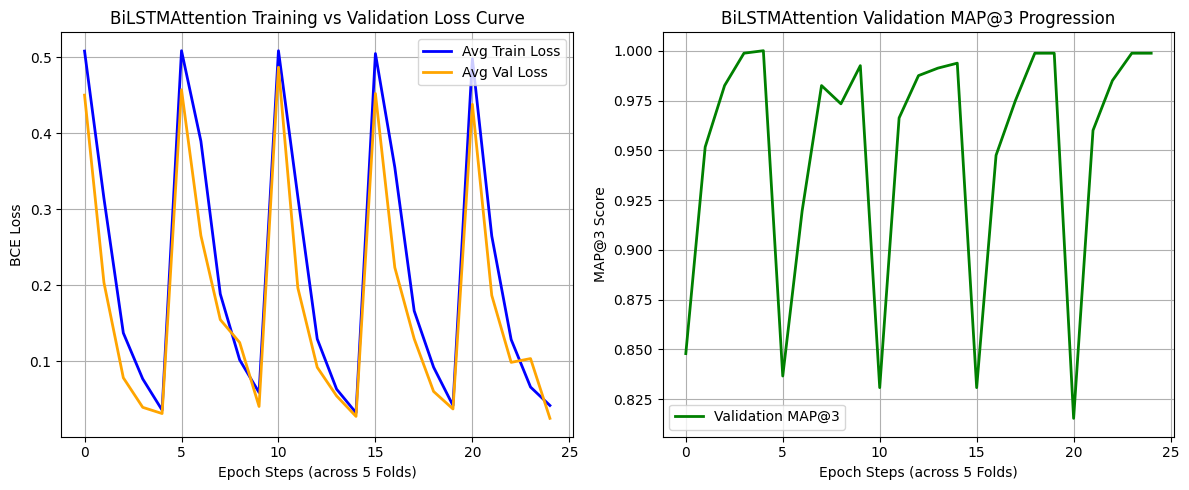

Successfully generated submission.csv!

          MODEL COMPARATIVE REPORT FOR REPORT DOCUMENTATION
            Model Architecture  MAP@3 Top-1 Acc Top-3 Acc F1 Score Log Loss
BiLSTMAttention Neural Network 0.9968    0.9935    1.0000   0.9937   0.0315

Submission Sample:


,ID,Prediction
0,1,A C E
1,2,B E C
2,3,B E D
3,4,E D C
4,5,C A E
5,6,D B A
6,7,E D C
7,8,B A E
8,9,C D A
9,10,B D A


In [8]:
# Cell 8: Plot Epoch Loss Curves & Comparative Report Table
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_train_loss, label='Avg Train Loss', color='blue', linewidth=2)
plt.plot(history_val_loss, label='Avg Val Loss', color='orange', linewidth=2)
plt.title('BiLSTMAttention Training vs Validation Loss Curve')
plt.xlabel('Epoch Steps (across 5 Folds)')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_val_map3, label='Validation MAP@3', color='green', linewidth=2)
plt.title('BiLSTMAttention Validation MAP@3 Progression')
plt.xlabel('Epoch Steps (across 5 Folds)')
plt.ylabel('MAP@3 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('bilstm_loss_curves.png')
plt.show()

test_preds = rank_preds(pair_test, tst_bilstm, test_df)

submission = pd.DataFrame({
    'ID': test_df['id'],
    'Prediction': [' '.join(p) for p in test_preds]
})

submission.to_csv('submission.csv', index=False)
print("Successfully generated submission.csv!")

report_df = pd.DataFrame([
    {"Model Architecture": "BiLSTMAttention Neural Network", "MAP@3": f"{m_bilstm['map3']:.4f}", "Top-1 Acc": f"{m_bilstm['top1_accuracy']:.4f}", "Top-3 Acc": f"{m_bilstm['top3_accuracy']:.4f}", "F1 Score": f"{m_bilstm['f1_score']:.4f}", "Log Loss": f"{oof_loss:.4f}"}
])

print("\n" + "="*70)
print("          MODEL COMPARATIVE REPORT FOR REPORT DOCUMENTATION")
print("="*70)
print(report_df.to_string(index=False))
print("="*70 + "\n")

print("Submission Sample:")
submission.head(10)
